# 09 — CPS Heterogeneity Analysis

This notebook tests whether the minimum wage employment effects differ across demographic groups —
specifically by **age group** and **gender**. Low-wage workers (teens, young adults, women)
are more likely to be minimum wage earners and therefore more likely to be affected.

**Design:** We merge the CPS state-level employment rates with the minimum wage panel and
run state-level DiD regressions (state FE + year FE) separately for each demographic group.
This is a complementary analysis to the border-county QCEW design — it uses a different
data source to probe *who* is affected.

**Inputs:**
- `data/intermediate/cps_panel.parquet` — state × year × age_group × gender employment rates
- `data/intermediate/min_wage_panel.parquet` — state × year minimum wages

**Specifications run:**
1. By age group (all workers, both genders combined)
2. By gender (all ages 16–64)
3. By age group × gender interaction
4. Focus on teens (16–19) and young adults (20–24) — the most exposed groups
5. Hours adjustment among employed young adults ages 20–24
6. Small-cell robustness for noisy CPS state-year demographic cells

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

ROOT = Path().resolve().parent
INTERMEDIATE = ROOT / "data" / "intermediate"
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

CPS_FILE = INTERMEDIATE / "cps_panel.parquet"
MW_FILE = INTERMEDIATE / "min_wage_panel.parquet"

FIRST_YEAR = 2004
LAST_YEAR = 2024

## 1. Load and merge inputs

In [2]:
cps = pd.read_parquet(CPS_FILE)
mw = pd.read_parquet(MW_FILE)

print("CPS panel shape :", cps.shape)
print("MW panel shape  :", mw.shape)
print("\nCPS columns:", cps.columns.tolist())
print("MW columns :", mw.columns.tolist())
print("\nAge groups in CPS:")
print(sorted(cps["age_group"].unique()))

CPS panel shape : (19278, 7)
MW panel shape  : (1113, 4)

CPS columns: ['state_fips', 'year', 'age_group', 'female', 'emp_rate', 'n_individuals', 'total_weight']
MW columns : ['state', 'state_fips', 'year', 'min_wage']

Age groups in CPS:
['16-19', '20-24', '25-34', '35-44', '45-54', '55-64']


In [3]:
# Filter to analysis years
cps = cps[cps["year"].between(FIRST_YEAR, LAST_YEAR)].copy()
mw = mw[mw["year"].between(FIRST_YEAR, LAST_YEAR)].copy()

# Merge min wage onto CPS via state_fips × year
merged = cps.merge(
    mw[["state_fips", "year", "min_wage", "state"]],
    on=["state_fips", "year"],
    how="left",
)

# Log minimum wage
merged["log_min_wage"] = np.log(merged["min_wage"])
merged["log_emp_rate"] = np.log(merged["emp_rate"].clip(lower=0.001))  # avoid log(0)

unmatched = merged["min_wage"].isna().sum()
print(f"Rows after merge    : {len(merged):,}")
print(f"Unmatched (no MW)   : {unmatched:,}  (should be 0)")
merged.head()

Rows after merge    : 19,278
Unmatched (no MW)   : 126  (should be 0)


,state_fips,year,age_group,female,emp_rate,n_individuals,total_weight,min_wage,state,log_min_wage,log_emp_rate
0,01,2004,16-19,0,0.824236,28,45902.84,5.15,AL,1.638997,-0.193298
1,01,2004,16-19,1,0.923777,39,51035.57,5.15,AL,1.638997,-0.079284
2,01,2004,20-24,0,0.894170,59,114027.51,5.15,AL,1.638997,-0.111859
3,01,2004,20-24,1,0.807976,66,119515.71,5.15,AL,1.638997,-0.213223
4,01,2004,25-34,0,0.950883,155,247350.31,5.15,AL,1.638997,-0.050364


## 2. Helper: run state + year FE regression

For the CPS analysis we use a simpler specification than the border-county design:
**state fixed effects + year fixed effects**, with standard errors clustered at the state level.

$$\log(emp\_rate_{st}) = \beta \log(mw_{st}) + \alpha_s + \delta_t + \varepsilon_{st}$$

In [4]:
def run_twfe(
    df,
    y_col="log_emp_rate",
    x_col="log_min_wage",
    state_col="state_fips",
    year_col="year",
):
    """Two-way FE regression (state + year) with state-clustered SEs."""
    d = df[[y_col, x_col, state_col, year_col]].dropna().copy()

    # Demean by state
    d["y_dm"] = d[y_col] - d.groupby(state_col)[y_col].transform("mean")
    d["x_dm"] = d[x_col] - d.groupby(state_col)[x_col].transform("mean")

    # Demean by year
    d["y_dm"] = d["y_dm"] - d.groupby(year_col)["y_dm"].transform("mean")
    d["x_dm"] = d["x_dm"] - d.groupby(year_col)["x_dm"].transform("mean")

    fit = sm.OLS(d["y_dm"], d[["x_dm"]]).fit(
        cov_type="cluster",
        cov_kwds={"groups": d[state_col]},
    )

    return {
        "beta": float(fit.params["x_dm"]),
        "se": float(fit.bse["x_dm"]),
        "t_stat": float(fit.tvalues["x_dm"]),
        "p_value": float(fit.pvalues["x_dm"]),
        "n_obs": int(fit.nobs),
        "n_states": int(d[state_col].nunique()),
    }

## 3. Heterogeneity by age group

In [5]:
AGE_GROUPS = ["16-19", "20-24", "25-34", "35-44", "45-54", "55-64"]

# female == -1 means both genders combined
age_data = merged[merged["female"] == -1].copy()

age_results = []
for ag in AGE_GROUPS:
    sub = age_data[age_data["age_group"] == ag]
    res = run_twfe(sub)
    res["age_group"] = ag
    age_results.append(res)

age_results = pd.DataFrame(age_results)
for col in ["beta", "se", "t_stat", "p_value"]:
    age_results[col] = age_results[col].round(4)

age_results["sig"] = age_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by age group (log emp_rate ~ log min_wage):")
print(
    age_results[["age_group", "beta", "se", "p_value", "sig", "n_obs"]].to_string(
        index=False
    )
)

Employment elasticity by age group (log emp_rate ~ log min_wage):
age_group    beta     se  p_value sig  n_obs
    16-19  0.0431 0.0248   0.0815   *   1064
    20-24 -0.0281 0.0141   0.0459  **   1064
    25-34 -0.0057 0.0079   0.4733       1064
    35-44 -0.0037 0.0052   0.4752       1064
    45-54  0.0047 0.0058   0.4114       1064
    55-64  0.0078 0.0055   0.1586       1064


## 4. Heterogeneity by gender

In [6]:
gender_results = []
for female_val, label in [(0, "Male"), (1, "Female")]:
    # All age groups combined — use individual-level weighted data collapsed to state×year
    sub = merged[
        (merged["female"] == female_val)
        & (
            merged["age_group"] == "25-34"
        )  # pick one age group to avoid double-counting
    ]
    # Better: reload cps_clean and collapse by state×year×female
    gender_results.append({"gender": label, "note": "see age×gender table below"})

# Proper gender breakdown: use all age groups, female=0 vs female=1
# Collapse each state×year×female across all age groups (weighted mean)
cps_clean = pd.read_parquet(ROOT / "data" / "intermediate" / "cps_clean.parquet")
cps_clean = cps_clean[cps_clean["year"].between(FIRST_YEAR, LAST_YEAR)]


def weighted_emp(g):
    return np.average(g["employed"], weights=g["weight"])


gender_panel = (
    cps_clean.groupby(["state_fips", "year", "female"])
    .apply(weighted_emp)
    .reset_index()
    .rename(columns={0: "emp_rate"})
)
gender_panel = gender_panel.merge(
    mw[["state_fips", "year", "min_wage"]], on=["state_fips", "year"], how="left"
)
gender_panel["log_min_wage"] = np.log(gender_panel["min_wage"])
gender_panel["log_emp_rate"] = np.log(gender_panel["emp_rate"].clip(lower=0.001))

gender_results = []
for female_val, label in [(0, "Male"), (1, "Female")]:
    sub = gender_panel[gender_panel["female"] == female_val]
    res = run_twfe(sub)
    res["gender"] = label
    gender_results.append(res)

gender_results = pd.DataFrame(gender_results)
for col in ["beta", "se", "t_stat", "p_value"]:
    gender_results[col] = gender_results[col].round(4)
gender_results["sig"] = gender_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by gender:")
print(
    gender_results[["gender", "beta", "se", "p_value", "sig", "n_obs"]].to_string(
        index=False
    )
)

Employment elasticity by gender:
gender    beta     se  p_value sig  n_obs
  Male -0.0033 0.0065   0.6080       1064
Female  0.0009 0.0059   0.8849       1064


/var/folders/rw/9x0mnb0n50zdfcqqs7nwzg8m0000gn/T/ipykernel_58933/1012147307.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_emp)


## 5. Age group × gender interaction

In [7]:
interaction_results = []
for ag in AGE_GROUPS:
    for female_val, gender_label in [(0, "Male"), (1, "Female")]:
        sub = merged[(merged["age_group"] == ag) & (merged["female"] == female_val)]
        if len(sub) < 50:
            continue
        res = run_twfe(sub)
        res["age_group"] = ag
        res["gender"] = gender_label
        interaction_results.append(res)

interaction_results = pd.DataFrame(interaction_results)
for col in ["beta", "se", "p_value"]:
    interaction_results[col] = interaction_results[col].round(4)
interaction_results["sig"] = interaction_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by age group × gender:")
print(
    interaction_results[
        ["age_group", "gender", "beta", "se", "p_value", "sig", "n_obs"]
    ].to_string(index=False)
)

Employment elasticity by age group × gender:
age_group gender    beta     se  p_value sig  n_obs
    16-19   Male  0.0302 0.0390   0.4392       1064
    16-19 Female  0.0602 0.0453   0.1842       1064
    20-24   Male -0.0431 0.0181   0.0171  **   1064
    20-24 Female -0.0116 0.0155   0.4559       1064
    25-34   Male -0.0047 0.0099   0.6383       1064
    25-34 Female -0.0073 0.0091   0.4216       1064
    35-44   Male -0.0027 0.0069   0.6948       1064
    35-44 Female -0.0046 0.0055   0.4016       1064
    45-54   Male  0.0053 0.0080   0.5079       1064
    45-54 Female  0.0043 0.0056   0.4476       1064
    55-64   Male  0.0060 0.0071   0.3964       1064
    55-64 Female  0.0096 0.0061   0.1168       1064


## 6. Coefficient plot — heterogeneity by age and gender

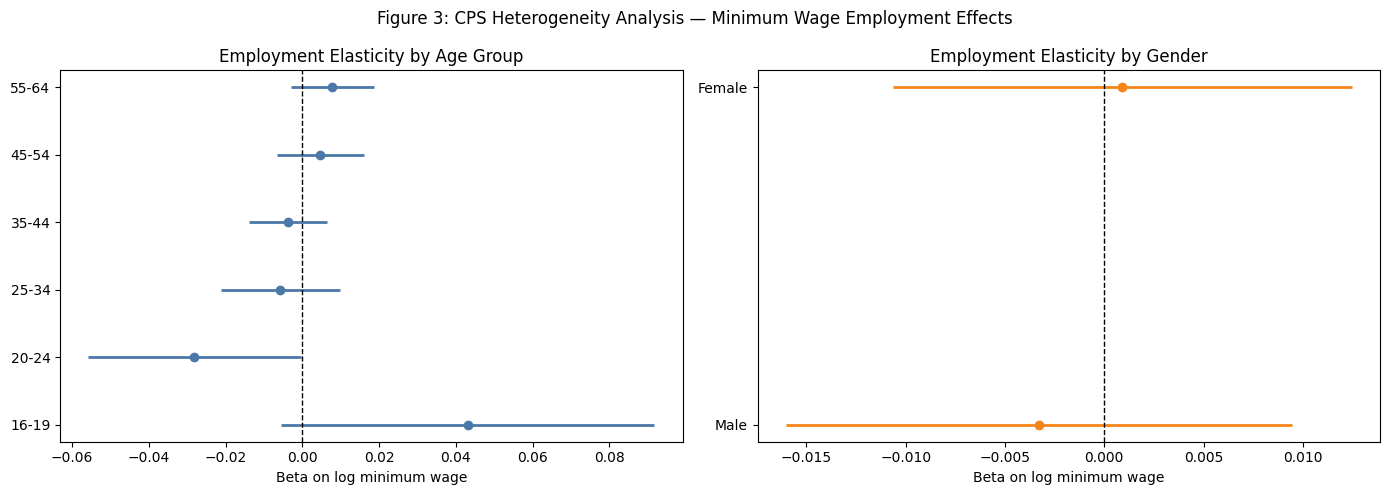

Figure 3 saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- Left panel: by age group ---
ax = axes[0]
y = np.arange(len(age_results))
ax.hlines(
    y,
    age_results["beta"] - 1.96 * age_results["se"],
    age_results["beta"] + 1.96 * age_results["se"],
    color="#4C78A8",
    lw=2,
)
ax.plot(age_results["beta"], y, "o", color="#4C78A8")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(age_results["age_group"])
ax.set_xlabel("Beta on log minimum wage")
ax.set_title("Employment Elasticity by Age Group")

# --- Right panel: by gender ---
ax2 = axes[1]
y2 = np.arange(len(gender_results))
ax2.hlines(
    y2,
    gender_results["beta"] - 1.96 * gender_results["se"],
    gender_results["beta"] + 1.96 * gender_results["se"],
    color="#F58518",
    lw=2,
)
ax2.plot(gender_results["beta"], y2, "o", color="#F58518")
ax2.axvline(0, color="black", ls="--", lw=1)
ax2.set_yticks(y2)
ax2.set_yticklabels(gender_results["gender"])
ax2.set_xlabel("Beta on log minimum wage")
ax2.set_title("Employment Elasticity by Gender")

plt.suptitle(
    "Figure 4: CPS Heterogeneity Analysis — Minimum Wage Employment Effects",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES / "fig4_cps_heterogeneity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

## 7. Hours Adjustment Among Young Adults

We also examine whether the negative CPS employment estimate for young adults could reflect adjustment on the intensive margin rather than headcount alone. If employers respond by reducing hours for workers who remain employed, average usual weekly hours among employed workers ages 20 to 24 should fall when minimum wages rise.

In [9]:
# Intensive-margin check for workers ages 20-24.
# UHRSWORKT records usual weekly hours worked. We restrict to employed workers
# with positive, finite hours and collapse to state-year weighted means.
cps_clean = pd.read_parquet(ROOT / "data" / "intermediate" / "cps_clean.parquet")
cps_clean = cps_clean[cps_clean["year"].between(FIRST_YEAR, LAST_YEAR)].copy()

hours_sample = cps_clean[
    (cps_clean["age_group"] == "20-24")
    & (cps_clean["employed"] == 1)
    & cps_clean["UHRSWORKT"].notna()
    & cps_clean["UHRSWORKT"].between(1, 98)
].copy()
hours_sample["weighted_hours"] = hours_sample["UHRSWORKT"] * hours_sample["weight"]

young_hours_panel = (
    hours_sample.groupby(["state_fips", "year"], as_index=False)
    .agg(
        weighted_hours=("weighted_hours", "sum"),
        total_weight=("weight", "sum"),
        n_individuals=("UHRSWORKT", "size"),
    )
)
young_hours_panel["avg_hours"] = (
    young_hours_panel["weighted_hours"] / young_hours_panel["total_weight"]
)
young_hours_panel = young_hours_panel.merge(
    mw[["state_fips", "year", "min_wage"]], on=["state_fips", "year"], how="left"
)
young_hours_panel["log_min_wage"] = np.log(young_hours_panel["min_wage"])
young_hours_panel["log_hours"] = np.log(young_hours_panel["avg_hours"].clip(lower=0.001))

young_hours_result = run_twfe(
    young_hours_panel,
    y_col="log_hours",
    x_col="log_min_wage",
)

young_hours_table = pd.DataFrame(
    [
        {
            "outcome": "Average usual weekly hours, ages 20-24",
            "beta": young_hours_result["beta"],
            "se": young_hours_result["se"],
            "p_value": young_hours_result["p_value"],
            "n_obs": young_hours_result["n_obs"],
            "n_states": young_hours_result["n_states"],
        }
    ]
)
for col in ["beta", "se", "p_value"]:
    young_hours_table[col] = young_hours_table[col].round(4)

young_hours_table

,outcome,beta,se,p_value,n_obs,n_states
0,"Average usual weekly hours, ages 20-24",-0.0046,0.0141,0.7428,1064,51


## 8. Small-Cell Robustness for CPS Estimates

We also check whether the CPS heterogeneity results are driven by noisy state-year demographic cells in small states. The robustness below reruns age-group estimates after dropping cells with fewer than 30 individual CPS observations.

In [10]:
MIN_CELL_N = 30

small_cell_results = []
for ag in AGE_GROUPS:
    samples = [
        ("All state-year cells", age_data[age_data["age_group"] == ag].copy()),
        (
            f"Cells with n >= {MIN_CELL_N}",
            age_data[
                (age_data["age_group"] == ag)
                & (age_data["n_individuals"] >= MIN_CELL_N)
            ].copy(),
        ),
    ]
    for sample_label, sub in samples:
        res = run_twfe(sub)
        small_cell_results.append(
            {
                "age_group": ag,
                "sample": sample_label,
                "beta": res["beta"],
                "se": res["se"],
                "p_value": res["p_value"],
                "n_obs": res["n_obs"],
                "n_states": res["n_states"],
            }
        )

small_cell_results = pd.DataFrame(small_cell_results)
small_cell_display = small_cell_results.copy()
for col in ["beta", "se", "p_value"]:
    small_cell_display[col] = small_cell_display[col].round(4)

small_cell_display

,age_group,sample,beta,se,p_value,n_obs,n_states
0,16-19,All state-year cells,0.0431,0.0248,0.0815,1064,51
1,16-19,Cells with n >= 30,0.0517,0.0244,0.0344,1000,50
2,20-24,All state-year cells,-0.0281,0.0141,0.0459,1064,51
3,20-24,Cells with n >= 30,-0.0276,0.0142,0.0515,1060,51
4,25-34,All state-year cells,-0.0057,0.0079,0.4733,1064,51
5,25-34,Cells with n >= 30,-0.0057,0.0079,0.4733,1064,51
6,35-44,All state-year cells,-0.0037,0.0052,0.4752,1064,51
7,35-44,Cells with n >= 30,-0.0037,0.0052,0.4752,1064,51
8,45-54,All state-year cells,0.0047,0.0058,0.4114,1064,51
9,45-54,Cells with n >= 30,0.0047,0.0058,0.4114,1064,51


In [11]:
young_adult_full = small_cell_results[
    (small_cell_results["age_group"] == "20-24")
    & (small_cell_results["sample"] == "All state-year cells")
].iloc[0]
young_adult_restricted = small_cell_results[
    (small_cell_results["age_group"] == "20-24")
    & (small_cell_results["sample"] == f"Cells with n >= {MIN_CELL_N}")
].iloc[0]

cps_robustness_table = pd.DataFrame(
    [
        {
            "check": "20-24 employment, all CPS cells",
            "beta": young_adult_full["beta"],
            "se": young_adult_full["se"],
            "p_value": young_adult_full["p_value"],
            "n_obs": young_adult_full["n_obs"],
            "n_states": young_adult_full["n_states"],
        },
        {
            "check": f"20-24 employment, cells with n >= {MIN_CELL_N}",
            "beta": young_adult_restricted["beta"],
            "se": young_adult_restricted["se"],
            "p_value": young_adult_restricted["p_value"],
            "n_obs": young_adult_restricted["n_obs"],
            "n_states": young_adult_restricted["n_states"],
        },
        {
            "check": "20-24 average weekly hours among employed",
            "beta": young_hours_result["beta"],
            "se": young_hours_result["se"],
            "p_value": young_hours_result["p_value"],
            "n_obs": young_hours_result["n_obs"],
            "n_states": young_hours_result["n_states"],
        },
    ]
)
for col in ["beta", "se", "p_value"]:
    cps_robustness_table[col] = cps_robustness_table[col].round(4)

cps_robustness_table

,check,beta,se,p_value,n_obs,n_states
0,"20-24 employment, all CPS cells",-0.0281,0.0141,0.0459,1064,51
1,"20-24 employment, cells with n >= 30",-0.0276,0.0142,0.0515,1060,51
2,20-24 average weekly hours among employed,-0.0046,0.0141,0.7428,1064,51


**How to read these CPS robustness checks:** The hours check does not show evidence that young adults adjust mainly through usual weekly hours among those still employed (β = -0.0046, SE = 0.0141, p = 0.743). The small-cell check shows that the 20-24 employment estimate is nearly unchanged after excluding state-year cells with fewer than 30 CPS observations (all cells: β = -0.0281, p = 0.046; restricted cells: β = -0.0276, p = 0.052). This suggests the young-adult employment result is not driven by very small CPS cells, although the restricted estimate is just above the 5% threshold under the expanded 2004-2024 CPS sample.